# DOES NOT WORK

Attempted both removing a feature + checking embeddings dissimilarity and predicting a given feature using X and y_pred concatenated. Neither worked, completely different results from calculating Shapley values.

In [11]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.ensemble import RandomForestClassifier
from mlresearch.datasets import MultiClassDatasets
from tabpfn import TabPFNRegressor
import shap
from tqdm.auto import tqdm

# just a simple toy dataset (all continuous features)
datasets = MultiClassDatasets(names=["AUTOUNIV AU7"]).download()
df = datasets["AUTOUNIV AU7"]

df = df.sample(500, random_state=42).reset_index(drop=True).astype(float)

# preprocess data (standardscaler)
df.loc[:, df.columns.drop("target")] = StandardScaler().fit_transform(
    df.loc[:, df.columns.drop("target")].values
)

X = df.loc[:, df.columns.drop("target")].values
y = (df["target"].values == 1).astype(int)  # binary classification

Datasets:   0%|          | 0/1 [00:00<?, ?it/s]

In [13]:
clf = RandomForestClassifier(random_state=42).fit(X[:250], y[:250])

shap_explainer = shap.Explainer(model=clf)
shap_explanations = shap_explainer(X[250:])
explanation_shap = shap_explanations.data
base_value = clf.predict_proba(X[:250])[:, 1].mean()

y_pred = clf.predict_proba(X[250:])[:, -1]

In [21]:
# base value + shap values = predicted probabilities
np.isclose(
    base_value + shap_explanations[:, :, 1].values.sum(axis=1), y_pred, atol=5e-3
).all()

np.True_

In [22]:
feature_idx = 0

# Get embeddings for base prediction task
pfn_embedder = TabPFNRegressor(n_estimators=1).fit(X[250:], y_pred)
embeddings_classifier = pfn_embedder.get_embeddings(X[250:])

explanation_pfn = np.zeros_like(X[250:], dtype=np.float32)
for feature_idx in tqdm(range(X.shape[1])):
    regressor = TabPFNRegressor(n_estimators=1).fit(
        np.delete(X, feature_idx, axis=1)[250:], y_pred
    )
    embeddings_regressor = regressor.get_embeddings(np.delete(X, feature_idx, axis=1))
    explanation_pfn[:, feature_idx] = np.diag(
        cosine_similarity(
            embeddings_classifier.squeeze(), embeddings_regressor.squeeze()
        )
    )

/var/home/joaofonseca/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/regressor.py:492: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(


  0%|          | 0/5 [00:00<?, ?it/s]

/var/home/joaofonseca/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/regressor.py:492: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(
/var/home/joaofonseca/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/regressor.py:492: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(
/var/home/joaofonseca/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/regressor.py:492: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider using a GPU or the tabpfn-client API: https://github.com/PriorLabs/tabpfn-client
  check_cpu_warning(
/var/home/joaofonseca/miniconda3/envs/tfm/lib/python3.12/site-packages/tabpfn/regressor.py:492: UserWarning: Running on CPU with more than 200 samples may be slow.
Consider us

In [23]:
xpfn = explanation_pfn - np.repeat(
    explanation_pfn.mean(axis=1).reshape(-1, 1),
    repeats=explanation_pfn.shape[1],
    axis=1,
)
xpfn = xpfn / xpfn.std()

In [24]:
error = y_pred - (xpfn.sum(axis=1) + base_value)
error = np.repeat(error.reshape(-1, 1), repeats=xpfn.shape[1], axis=1) / xpfn.shape[1]
xpfn_corrected = xpfn + error

In [25]:
# Apply correction to ensure that base value + pfn values = predicted probabilities
# explanation_pfn = explanation_pfn - explanation_pfn.mean(axis=1, keepdims=True) + base_value

# Sanity check
np.isclose(base_value + xpfn_corrected.sum(axis=1), y_pred, atol=1e-3).all()

np.True_

In [26]:
xpfn

array([[-0.52406365, -0.83178717, -0.91550666,  1.0562581 ,  1.2153717 ],
       [-0.56903565,  0.64563584,  0.71737313, -0.2058752 , -0.5882149 ],
       [-0.32417953,  1.1441791 ,  0.8919703 , -0.5141045 , -1.1979431 ],
       ...,
       [-0.15109964,  0.83906204,  1.0091853 , -0.02832146, -1.6688262 ],
       [ 0.10597204,  0.3940106 ,  0.30838487, -0.09675201, -0.7115377 ],
       [-1.4123381 , -0.3602427 ,  0.8179377 , -0.62330544,  1.5778708 ]],
      shape=(250, 5), dtype=float32)

In [27]:
xpfn_corrected[1]

array([-0.5963483 ,  0.6183232 ,  0.69006049, -0.23318785, -0.61552752])

In [28]:
explanation_shap[1]

array([-0.23095306, -0.65197057,  0.58694786, -0.4953381 ,  1.09469092])

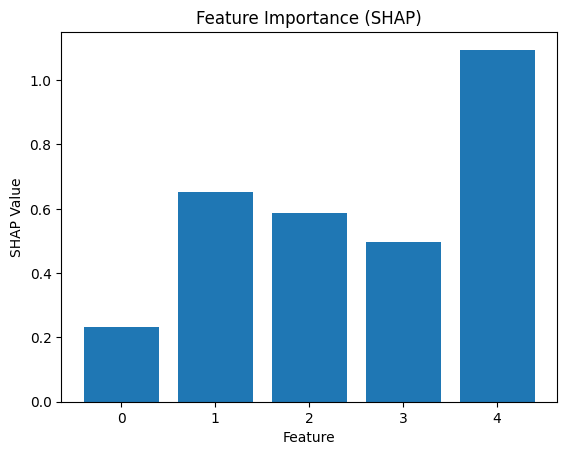

In [29]:
import matplotlib.pyplot as plt

plt.bar(range(len(explanation_shap[1])), np.abs(explanation_shap[1]))
plt.xlabel("Feature")
plt.ylabel("SHAP Value")
plt.title("Feature Importance (SHAP)")
plt.show()

<BarContainer object of 5 artists>

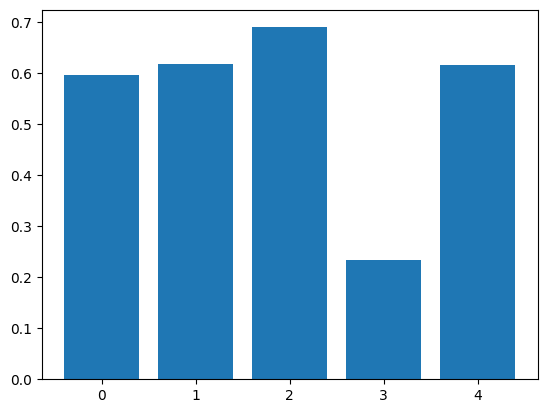

In [30]:
plt.bar(range(len(xpfn_corrected[1])), np.abs(xpfn_corrected[1]))